# Credit Card Fraud Detection
## Phase 1: Exploratory Data Analysis & Rule-Based Detection

This notebook documents EDA process and development of a rule-based fraud detection system using the Kaggle Credit Card Fraud Detection dataset (MLG-ULB).

The goal is to identify which features best separate fraudulent from legitimate transactions, then build threshold-based detection rules using those features. 

In [48]:
import pandas as pd
from scipy import stats

df = pd.read_csv(r"C:\Users\alana\OneDrive\Documents\fraud-detection\data\creditcard.csv.csv")

## 1. Initial Data Exploration
Here, I'm getting a view of the dataset by looking at its shape, structure, and class distribution.

In [36]:
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [38]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [39]:
fraud_pct = (df['Class'].value_counts()[1] / len(df)) * 100
legit_pct = (df['Class'].value_counts()[0] / len(df)) * 100

print(f"Fraud: {fraud_pct:.4f}%")
print(f"Legitimate: {legit_pct:.4f}%")

Fraud: 0.1727%
Legitimate: 99.8273%


### Key Finding
The dataset is heavily imbalanced with only 0.17% of transactions being fraudulent. This means I have to be careful about using accuracy as a metric for a succesful model. If I flag every transaction as legitimate, my model will technically be 99.83% accurate, but catch absolutely zero fraud. Precision, recall, and F1 score will be used instead.

## 2. Feature Analysis - Amount
I'm going to investigate whether the transaction amount alone is a reliable fraud signal.

In [40]:
print("Fraud transactions:")
print(df[df['Class']==1]['Amount'].describe())

print("\nLegitimate transactions:")
print(df[df['Class']==0]['Amount'].describe())

Fraud transactions:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Legitimate transactions:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


### Key Finding
Fraudulent transactions median amount of only $9.25 which is much lower than anticipated. This does reflect a common fraud pattern of small test transactions to verify stolen cards before making larger purchases.

The mean is pulled higher by a small number of very large transactions. That distribution overlaps heavily with legitimate transactions. Amount alone is a weak signal

## 3. Z-Score Analysis - Amount
Here, im going to standardize Amount values to measure how far each transaction deviates from the mean. This allows me to compare across different features on the same scale. 

In [41]:
df['Amount_Zscore'] = stats.zscore(df['Amount'])

print("Fraud Amount Z-scores:")
print(df[df['Class']==1]['Amount_Zscore'].describe())

print("\nLegitimate Amount Z-scores:")
print(df[df['Class']==0]['Amount_Zscore'].describe())

Fraud Amount Z-scores:
count    492.000000
mean       0.135382
std        1.026242
min       -0.353229
25%       -0.349231
50%       -0.316247
75%        0.070128
max        8.146182
Name: Amount_Zscore, dtype: float64

Legitimate Amount Z-scores:
count    284315.000000
mean         -0.000234
std           0.999942
min          -0.353229
25%          -0.330640
50%          -0.265271
75%          -0.045177
max         102.362243
Name: Amount_Zscore, dtype: float64


In [42]:
# How many fraud cases fall beyond 3 standard deviations?
extreme_fraud = df[(df['Class']==1) & (df['Amount_Zscore'] > 3)]['Amount_Zscore'].count()
print(f"Fraud cases beyond Z-score of 3: {extreme_fraud} / 492 ({extreme_fraud/492*100:.2f}%)")

Fraud cases beyond Z-score of 3: 11 / 492 (2.24%)


## Key Finding 
Only 11 out of 492 fraud cases (2.2%) have an AMount Z-score above 3. 
A threshold of 3 standard deviations on Amount alone would miss 97.8% of fraud. The Amount column alone is not enough to detect fraud efficiently.

## 4. Feature Analysis - V Columns
The V1-V28 columns are PCA-tranformed behavioral features. I compare means between fraud and legitimate transactions to identify which columns show the strongest separation. 

In [43]:
print("Fraud cases — selected V columns:")
print(df[df['Class']==1][['V1','V2','V3','V4','V14','V17']].describe())

print("\nLegitimate cases — selected V columns:")
print(df[df['Class']==0][['V1','V2','V3','V4','V14','V17']].describe())

Fraud cases — selected V columns:
               V1          V2          V3          V4         V14         V17
count  492.000000  492.000000  492.000000  492.000000  492.000000  492.000000
mean    -4.771948    3.623778   -7.033281    4.542029   -6.971723   -6.665836
std      6.783687    4.291216    7.110937    2.873318    4.278940    6.970618
min    -30.552380   -8.402154  -31.103685   -1.313275  -19.214325  -25.162799
25%     -6.036063    1.188226   -8.643489    2.373050   -9.692723  -11.945057
50%     -2.342497    2.717869   -5.075257    4.177147   -6.729720   -5.302949
75%     -0.419200    4.971257   -2.276185    6.348729   -4.282821   -1.341940
max      2.132386   22.057729    2.250210   12.114672    3.442422    6.739384

Legitimate cases — selected V columns:
                  V1             V2             V3             V4  \
count  284315.000000  284315.000000  284315.000000  284315.000000   
mean        0.008258      -0.006271       0.012171      -0.007860   
std         1.929

### Key Finding
Legitimate transactions seem to cluster almost perfectly around zero across all V columns. Fraud transactions shoe significant deviations from zero. I ran the test initially with all V columns. I closed in on the features that seemed most significant. V1, 3, 4, 14, and 17 are strong signals. V14 shows the clearest separation and will serve as an anchor for my rule based system. 

## 5. Rule-Based Detection System
Using threshold-based rules on the strongest V columns flag fradulent transactions. Each rule is measured by a catch rate (recall) and false positives. 

I start with a single rule and and add conditions systematically, measuring the impact of each addition before proceeding. 

In [44]:
def evaluate_rule(flagged, total_fraud=492):
    fraud_caught = flagged[flagged['Class'] == 1].shape[0]
    false_positives = flagged[flagged['Class'] == 0].shape[0]
    catch_rate = fraud_caught / total_fraud * 100
    print(f"Fraud caught: {fraud_caught} / {total_fraud}")
    print(f"False positives: {false_positives}")
    print(f"Catch rate: {catch_rate:.2f}%")

### Rule 1 - V14 Single Threshold
Testing V14 at multiple thresholds to understand the precision/recall tradeoff.

In [45]:
for threshold in [-5, -6, -7]:
    print(f"\nV14 < {threshold}:")
    evaluate_rule(df[df['V14'] < threshold])


V14 < -5:
Fraud caught: 324 / 492
False positives: 217
Catch rate: 65.85%

V14 < -6:
Fraud caught: 284 / 492
False positives: 120
Catch rate: 57.72%

V14 < -7:
Fraud caught: 235 / 492
False positives: 83
Catch rate: 47.76%


### Rule 2 - V14 + V17 Combined
Adding V17 as a second AND condition to reduce false positives. Transactions must now trip both thresholds to be flagged.

In [46]:
for v17_threshold in [-6, -4, -3, -2]:
    print(f'\nV14 < -6 AND V17 < {v17_threshold}:')
    evaluate_rule(df[(df['V14'] < -6) & (df['V17'] < v17_threshold)])
    


V14 < -6 AND V17 < -6:
Fraud caught: 187 / 492
False positives: 38
Catch rate: 38.01%

V14 < -6 AND V17 < -4:
Fraud caught: 220 / 492
False positives: 38
Catch rate: 44.72%

V14 < -6 AND V17 < -3:
Fraud caught: 230 / 492
False positives: 43
Catch rate: 46.75%

V14 < -6 AND V17 < -2:
Fraud caught: 242 / 492
False positives: 49
Catch rate: 49.19%


## Rule 3 - Adding V3 as a second Detection Path
V3 alone produces too many false positives as a standalone OR condition. Pairing it with V14 keeps precision high while expanding coverage.

In [47]:
print("Best combines rule:")
flagged = df[((df['V14'] < -6) & (df['V17'] < -4)) | ((df['V3'] < -5) & (df['V14'] < -6))]
evaluate_rule(flagged)

Best combines rule:
Fraud caught: 266 / 492
False positives: 46
Catch rate: 54.07%


## 6. Rule-Based System Results & Limitations

**Best rule:**
`(V14 < -6 AND V17 < -4) OR (V3 < -5 AND V14 < -6)`

| Metric | Result |
|--------|--------|
| Fraud caught | 266 / 492 |
| Catch rate | 54.07% |
| False positives | 46 |

**Key limitation:**
V14 acts as the anchor for every effective rule. This means the system is 
blind to fraud cases where V14 does not appear suspicious. Additional columns 
tested (V1, V4) added minimal coverage at the cost of more false positives.

The rule-based system has reached its ceiling at ~54% catch rate.
The remaining 46% of fraud cases require a machine learning approach 
capable of finding complex, non-linear patterns across all features simultaneously.

**Next: Phase 2 — Machine Learning Models**

In [49]:
print("Fraud transactions — Time:")
print(df[df['Class']==1]['Time'].describe())

print("\nLegitimate transactions — Time:")
print(df[df['Class']==0]['Time'].describe())

Fraud transactions — Time:
count       492.000000
mean      80746.806911
std       47835.365138
min         406.000000
25%       41241.500000
50%       75568.500000
75%      128483.000000
max      170348.000000
Name: Time, dtype: float64

Legitimate transactions — Time:
count    284315.000000
mean      94838.202258
std       47484.015786
min           0.000000
25%       54230.000000
50%       84711.000000
75%      139333.000000
max      172792.000000
Name: Time, dtype: float64


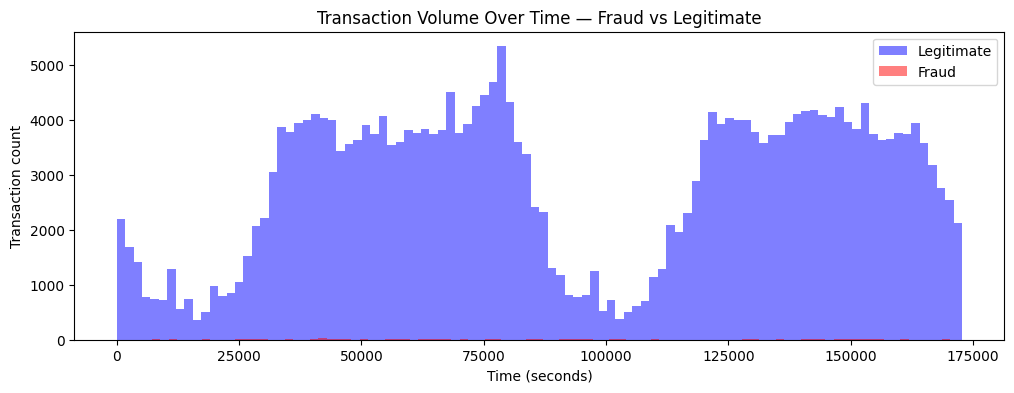

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.hist(df[df['Class']==0]['Time'], bins=100, alpha=0.5, label='Legitimate', color='blue')
plt.hist(df[df['Class']==1]['Time'], bins=100, alpha=0.5, label='Fraud', color='red')
plt.xlabel('Time (seconds)')
plt.ylabel('Transaction count')
plt.title('Transaction Volume Over Time — Fraud vs Legitimate')
plt.legend()
plt.show()

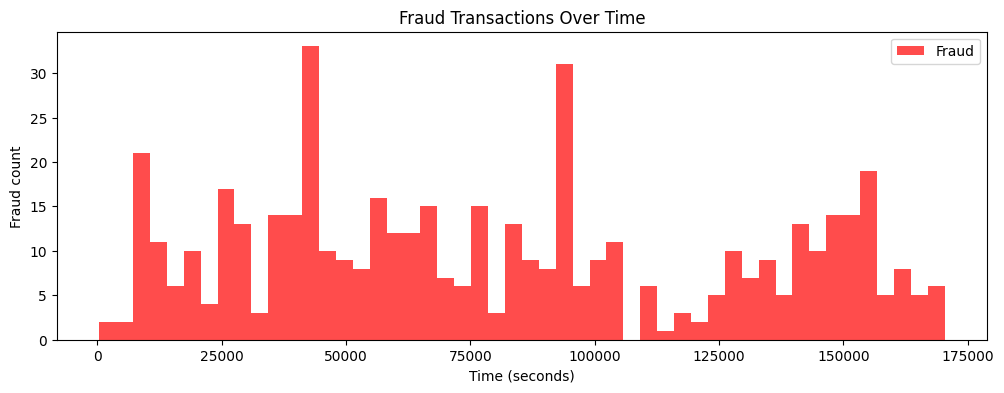

In [51]:
plt.figure(figsize=(12,4))
plt.hist(df[df['Class']==1]['Time'], bins=50, color='red', alpha=0.7, label='Fraud')
plt.xlabel('Time (seconds)')
plt.ylabel('Fraud count')
plt.title('Fraud Transactions Over Time')
plt.legend()
plt.show()

### Time Analysis Finding
After reviewing my threshold-based hardcoded program, I realized I didn't include the Time column in my initial analysis. 

Fraud does not follow the natural day/night transaction cycle that legitimate transactions exhibit. Fraud activity persists even through low-volume periods, which suggests potential value as a supporting signal in future ML models. Not used as a standalone rule due to the lack of absolute timestamp data. 